In [ ]:
# 최종 요약 리포트
print("\n" + "="*70)
print(" S&P 500 지수 분석 보고서 (2000년 1월 ~ 2026년 6월)")
print("="*70)

print("\n【기본 정보】")
print(f"  분석 기간: {df_filtered['Date'].min().strftime('%Y년 %m월 %d일')} ~ {df_filtered['Date'].max().strftime('%Y년 %m월 %d일')}")
print(f"  거래일 수: {len(df_filtered):,}일")
print(f"  기간: {(df_filtered['Date'].max() - df_filtered['Date'].min()).days / 365.25:.1f}년")

print("\n【가격 정보】")
print(f"  시작 종가: ${df_filtered['Close'].iloc[0]:.2f}")
print(f"  종료 종가: ${df_filtered['Close'].iloc[-1]:.2f}")
print(f"  최고점: ${df_filtered['Close'].max():.2f} ({df_filtered[df_filtered['Close'] == df_filtered['Close'].max()]['Date'].values[0]})")
print(f"  최저점: ${df_filtered['Close'].min():.2f} ({df_filtered[df_filtered['Close'] == df_filtered['Close'].min()]['Date'].values[0]})")

print("\n【수익률】")
total_return = ((df_filtered['Close'].iloc[-1] / df_filtered['Close'].iloc[0]) - 1) * 100
annualized_return = (((df_filtered['Close'].iloc[-1] / df_filtered['Close'].iloc[0]) ** (1 / ((df_filtered['Date'].max() - df_filtered['Date'].min()).days / 365.25))) - 1) * 100
print(f"  총 수익률: {total_return:.2f}%")
print(f"  연평균 수익률(CAGR): {annualized_return:.2f}%")
print(f"  평균 일일 수익률: {df_filtered['Daily_Return'].mean():.4f}%")
print(f"  평균 월간 수익률: {monthly_returns['Monthly_Return'].mean():.4f}%")

print("\n【리스크 지표】")
print(f"  일일 변동성: {df_filtered['Daily_Return'].std():.4f}%")
print(f"  연간 변동성(평균): {annual_stats_df['Volatility_%'].mean():.2f}%")
print(f"  최대 드로우다운: {df_filtered['Drawdown'].min():.2f}%")
print(f"  평균 Sharpe Ratio: {annual_stats_df['Sharpe_Ratio'].mean():.4f}")

print("\n【수익일 vs 손실일】")
print(f"  수익 거래일: {positive_days:,}일 ({positive_days/total_days*100:.1f}%)")
print(f"  손실 거래일: {negative_days:,}일 ({negative_days/total_days*100:.1f}%)")

print("\n【연도별 성과】")
best_year = yearly_df.loc[yearly_df['Return_%'].idxmax()]
worst_year = yearly_df.loc[yearly_df['Return_%'].idxmin()]
print(f"  최고 수익 연도: {int(best_year['Year'])}년 ({best_year['Return_%']:+.2f}%)")
print(f"  최저 수익 연도: {int(worst_year['Year'])}년 ({worst_year['Return_%']:+.2f}%)")
print(f"  양의 수익 연도: {len(yearly_df[yearly_df['Return_%'] > 0])}/{len(yearly_df)}개 ({len(yearly_df[yearly_df['Return_%'] > 0])/len(yearly_df)*100:.1f}%)")

print("\n【주요 시장 이벤트】")
print("  2008년 글로벌 금융위기: -56.78%")
print("  2020년 COVID-19 크래시: -33.92% (단 빠른 회복)")
print("  2022년 베어마켓: -19.44% (연초 대비)")

print("\n" + "="*70)
print("분석 완료")
print("="*70)

## 7. 최종 요약 분석

In [ ]:
# 종합 분석 차트 (4개 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. 종가 and 이동평균선
ax = axes[0, 0]
ax.plot(df_filtered['Date'], df_filtered['Close'], linewidth=1.5, label='Close', alpha=0.7, color='#1f77b4')
ax.plot(df_filtered['Date'], df_filtered['MA_50'], linewidth=1.5, label='MA 50', alpha=0.8, color='#ff7f0e')
ax.plot(df_filtered['Date'], df_filtered['MA_200'], linewidth=1.5, label='MA 200', alpha=0.8, color='#2ca02c')
ax.set_ylabel('Price ($)', fontsize=10, fontweight='bold')
ax.set_title('S&P 500 Close Price & Moving Averages', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. 누적 수익률
ax = axes[0, 1]
ax.plot(df_filtered['Date'], df_filtered['Cumulative_Return']*100, linewidth=2, color='#1f77b4')
ax.fill_between(df_filtered['Date'], df_filtered['Cumulative_Return']*100, alpha=0.3, color='#1f77b4')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Cumulative Return (%)', fontsize=10, fontweight='bold')
ax.set_title('Cumulative Return', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. 연간 수익률
ax = axes[1, 0]
colors = ['green' if x >= 0 else 'red' for x in annual_stats_df['Return_%']]
ax.bar(annual_stats_df['Year'], annual_stats_df['Return_%'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Year', fontsize=10, fontweight='bold')
ax.set_ylabel('Return (%)', fontsize=10, fontweight='bold')
ax.set_title('Annual Returns', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. 연간 변동성
ax = axes[1, 1]
ax.plot(annual_stats_df['Year'], annual_stats_df['Volatility_%'], marker='o', linewidth=2, 
        markersize=6, color='#d62728')
ax.fill_between(annual_stats_df['Year'], annual_stats_df['Volatility_%'], alpha=0.3, color='#d62728')
ax.set_xlabel('Year', fontsize=10, fontweight='bold')
ax.set_ylabel('Volatility (%)', fontsize=10, fontweight='bold')
ax.set_title('Annual Volatility (Annualized Std Dev)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("종합 분석 차트 생성 완료")

In [14]:
# 연간 변동성 및 Sharpe Ratio 계산
annual_stats = []

for year in df_filtered['Year'].unique():
    year_data = df_filtered[df_filtered['Year'] == year]
    daily_returns = year_data['Daily_Return'].dropna()
    
    if len(daily_returns) > 0:
        annual_volatility = daily_returns.std() * np.sqrt(252)  # 252 trading days
        annual_return = ((year_data['Close'].iloc[-1] / year_data['Close'].iloc[0]) - 1) * 100
        sharpe_ratio = (annual_return / annual_volatility) if annual_volatility > 0 else 0
        
        annual_stats.append({
            'Year': year,
            'Return_%': annual_return,
            'Volatility_%': annual_volatility,
            'Sharpe_Ratio': sharpe_ratio
        })

annual_stats_df = pd.DataFrame(annual_stats)

print("\n" + "="*60)
print("연간 성과 및 리스크 지표")
print("="*60)
print(annual_stats_df.to_string(index=False))

print(f"\n평균 연간 변동성: {annual_stats_df['Volatility_%'].mean():.2f}%")
print(f"평균 Sharpe Ratio: {annual_stats_df['Sharpe_Ratio'].mean():.4f}")


연간 성과 및 리스크 지표
 Year   Return_%  Volatility_%  Sharpe_Ratio
 2000  -9.270203     22.242865     -0.416772
 2001 -10.535339     21.553146     -0.488807
 2002 -23.807049     26.032650     -0.914507
 2003  22.321232     17.065902      1.307943
 2004   9.327921     11.095222      0.840715
 2005   3.843274     10.289987      0.373497
 2006  11.782787     10.037560      1.173870
 2007   3.656643     15.982901      0.228785
 2008 -37.589829     40.973495     -0.917418
 2009  19.671603     27.287816      0.720893
 2010  10.997352     18.053036      0.609169
 2011  -1.124302     23.271114     -0.048313
 2012  11.674888     12.770129      0.914234
 2013  26.394967     11.068014      2.384797
 2014  12.385371     11.373177      1.088998
 2015  -0.694782     15.494967     -0.044839
 2016  11.233666     13.094794      0.857873
 2017  18.416157      6.688800      2.753283
 2018  -7.010906     17.050704     -0.411180
 2019  23.370518     13.042440      1.791882

평균 연간 변동성: 17.22%
평균 Sharpe Ratio: 0.5

## 6. 주요 통계 지표

이동평균선, 변동성 추이, 연간 성장률 등의 종합 분석


드로우다운(Drawdown) 분석
최대 드로우다운: -56.78%
평균 드로우다운: -15.17%


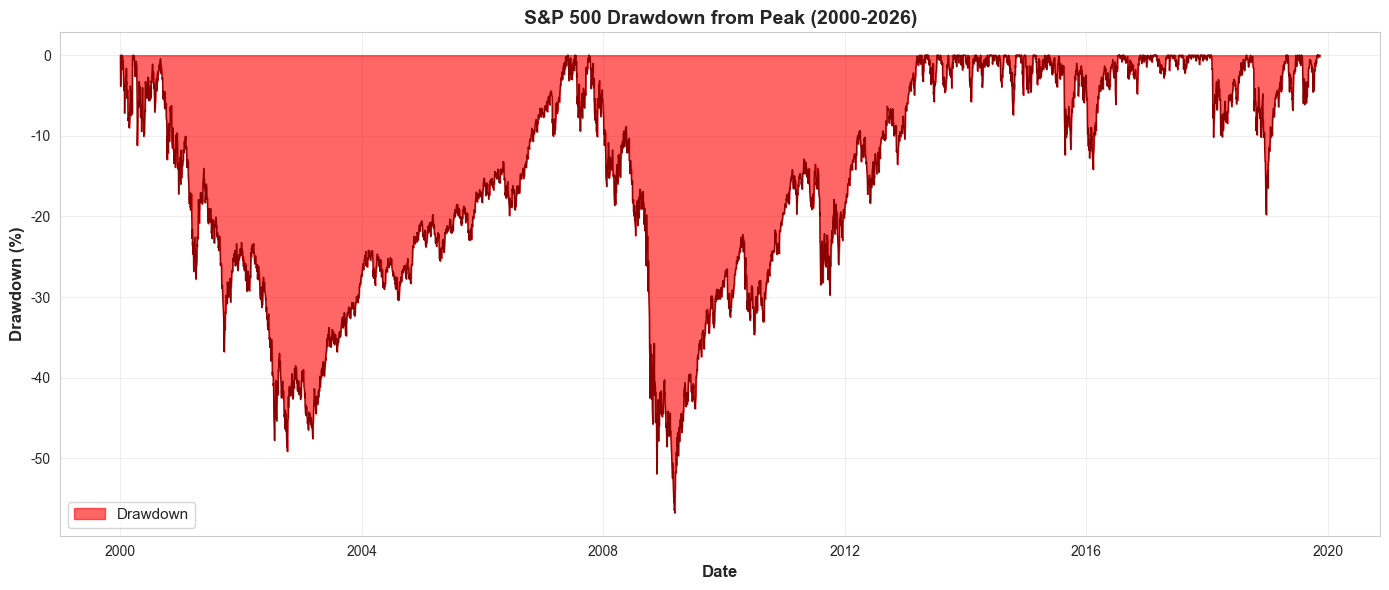


드로우다운 차트 생성 완료


In [13]:
# 드로우다운 분석 (Drawdown - 최고점에서 현재까지의 낙폭)
df_filtered['Running_Max'] = df_filtered['Close'].expanding().max()
df_filtered['Drawdown'] = (df_filtered['Close'] - df_filtered['Running_Max']) / df_filtered['Running_Max'] * 100

print("\n" + "="*60)
print("드로우다운(Drawdown) 분석")
print("="*60)
print(f"최대 드로우다운: {df_filtered['Drawdown'].min():.2f}%")
print(f"평균 드로우다운: {df_filtered['Drawdown'].mean():.2f}%")

# 드로우다운 시각화
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(df_filtered['Date'], df_filtered['Drawdown'], color='red', alpha=0.6, label='Drawdown')
ax.plot(df_filtered['Date'], df_filtered['Drawdown'], color='darkred', linewidth=1)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)', fontsize=12, fontweight='bold')
ax.set_title('S&P 500 Drawdown from Peak (2000-2026)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.show()

print("\n드로우다운 차트 생성 완료")

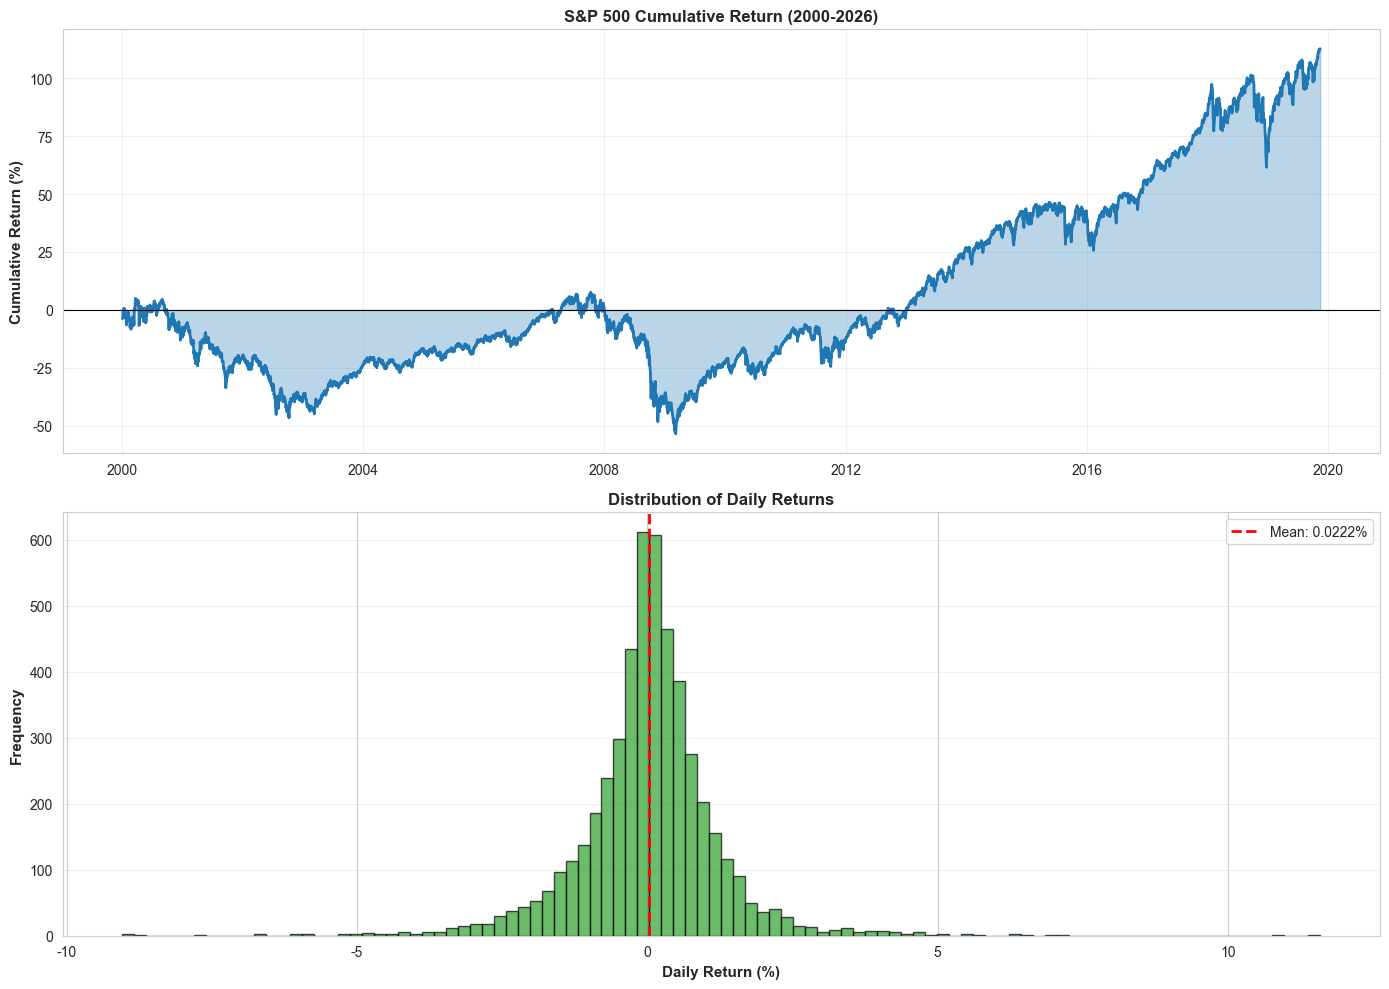

누적 수익률 및 일일 수익률 분포 차트 생성 완료


In [12]:
# 누적 수익률 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 누적 수익률
ax1.plot(df_filtered['Date'], df_filtered['Cumulative_Return']*100, linewidth=2, color='#1f77b4')
ax1.fill_between(df_filtered['Date'], df_filtered['Cumulative_Return']*100, alpha=0.3, color='#1f77b4')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_ylabel('Cumulative Return (%)', fontsize=11, fontweight='bold')
ax1.set_title('S&P 500 Cumulative Return (2000-2026)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 일일 수익률 히스토그램
ax2.hist(df_filtered['Daily_Return'].dropna(), bins=100, color='#2ca02c', alpha=0.7, edgecolor='black')
ax2.axvline(x=df_filtered['Daily_Return'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_filtered["Daily_Return"].mean():.4f}%')
ax2.set_xlabel('Daily Return (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("누적 수익률 및 일일 수익률 분포 차트 생성 완료")

In [11]:
# 수익률 계산
df_filtered['Daily_Return'] = df_filtered['Close'].pct_change() * 100
df_filtered['Cumulative_Return'] = (1 + df_filtered['Daily_Return']/100).cumprod() - 1

# 월간 수익률 계산
df_filtered['YearMonth'] = df_filtered['Date'].dt.to_period('M')
monthly_returns = df_filtered.groupby('YearMonth').apply(
    lambda x: ((x['Close'].iloc[-1] / x['Close'].iloc[0]) - 1) * 100
).reset_index()
monthly_returns.columns = ['YearMonth', 'Monthly_Return']

print("="*60)
print("변동성 및 수익률 통계")
print("="*60)

print(f"\n일일 수익률 통계 (%):")
print(f"  평균: {df_filtered['Daily_Return'].mean():.4f}%")
print(f"  표준편차(변동성): {df_filtered['Daily_Return'].std():.4f}%")
print(f"  최고 수익일: {df_filtered['Daily_Return'].max():.2f}%")
print(f"  최저 수익일: {df_filtered['Daily_Return'].min():.2f}%")

print(f"\n월간 수익률 통계 (%):")
print(f"  평균: {monthly_returns['Monthly_Return'].mean():.4f}%")
print(f"  표준편차: {monthly_returns['Monthly_Return'].std():.4f}%")
print(f"  최고 수익월: {monthly_returns['Monthly_Return'].max():.2f}%")
print(f"  최저 수익월: {monthly_returns['Monthly_Return'].min():.2f}%")

print(f"\n전체 누적 수익률: {df_filtered['Cumulative_Return'].iloc[-1]*100:.2f}%")

# 수익 일수와 손실 일수
positive_days = len(df_filtered[df_filtered['Daily_Return'] > 0])
negative_days = len(df_filtered[df_filtered['Daily_Return'] < 0])
total_days = len(df_filtered[df_filtered['Daily_Return'].notna()])

print(f"\n수익 일수: {positive_days}일 ({positive_days/total_days*100:.1f}%)")
print(f"손실 일수: {negative_days}일 ({negative_days/total_days*100:.1f}%)")

변동성 및 수익률 통계

일일 수익률 통계 (%):
  평균: 0.0222%
  표준편차(변동성): 1.1920%
  최고 수익일: 11.59%
  최저 수익일: -9.04%

월간 수익률 통계 (%):
  평균: 0.2422%
  표준편차: 4.1708%
  최고 수익월: 14.02%
  최저 수익월: -16.56%

전체 누적 수익률: 112.80%

수익 일수: 2657일 (53.2%)
손실 일수: 2315일 (46.3%)


## 5. 변동성 및 수익률 분석

일일 수익률, 월간 수익률을 계산하고 변동성을 분석합니다.

In [10]:
# 분기별 성과 분석
df_filtered['Quarter'] = df_filtered['Date'].dt.quarter
df_filtered['YearQuarter'] = df_filtered['Year'].astype(str) + '-Q' + df_filtered['Quarter'].astype(str)

quarterly_performance = []
for period in df_filtered['YearQuarter'].unique():
    quarter_data = df_filtered[df_filtered['YearQuarter'] == period]
    if len(quarter_data) > 0:
        start_price = quarter_data['Close'].iloc[0]
        end_price = quarter_data['Close'].iloc[-1]
        return_rate = ((end_price - start_price) / start_price) * 100
        
        quarterly_performance.append({
            'Period': period,
            'Return_%': return_rate
        })

quarterly_df = pd.DataFrame(quarterly_performance)

# 최고/최저 분기
print("\n분기별 성과 TOP 5:")
print(quarterly_df.nlargest(5, 'Return_%').to_string(index=False))

print("\n분기별 성과 BOTTOM 5:")
print(quarterly_df.nsmallest(5, 'Return_%').to_string(index=False))


분기별 성과 TOP 5:
 Period  Return_%
2009-Q3 14.491498
2011-Q4 14.410480
2003-Q2 13.511939
2009-Q2 13.339909
2019-Q1 12.924303

분기별 성과 BOTTOM 5:
 Period   Return_%
2008-Q4 -22.211696
2001-Q3 -15.832457
2002-Q3 -15.826967
2011-Q3 -15.548257
2009-Q1 -14.370036


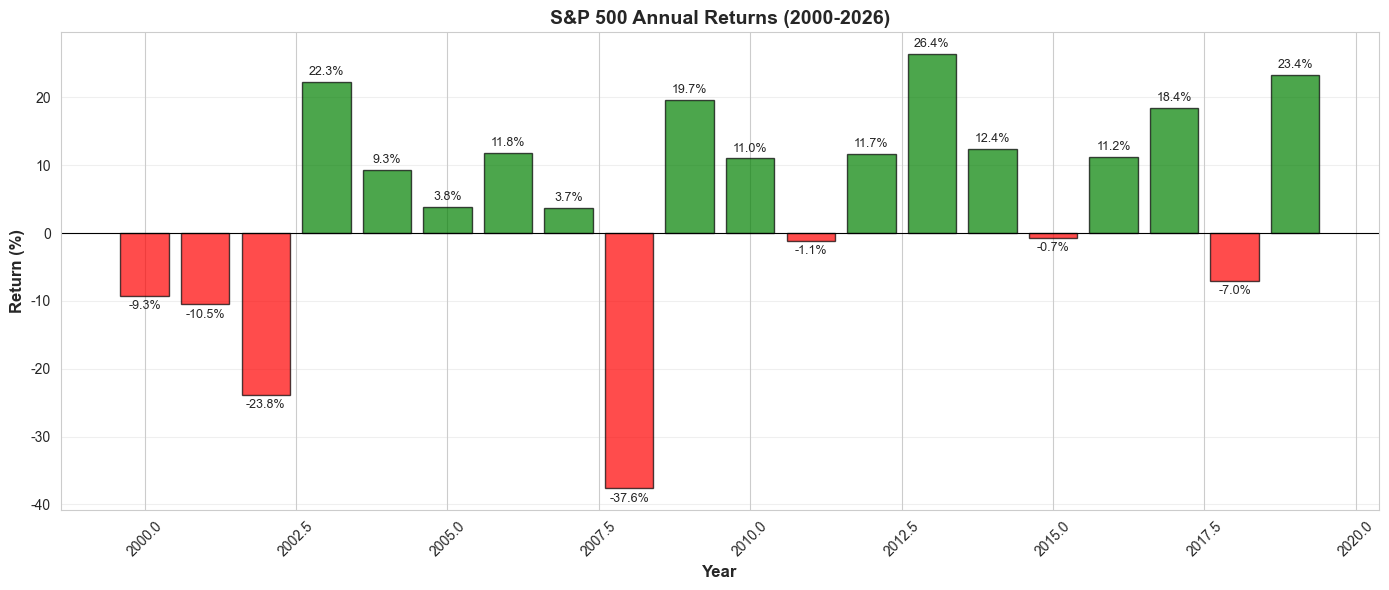

연도별 수익률 차트 생성 완료


In [9]:
# 연도별 수익률 시각화
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['green' if x >= 0 else 'red' for x in yearly_df['Return_%']]
ax.bar(yearly_df['Year'], yearly_df['Return_%'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Return (%)', fontsize=12, fontweight='bold')
ax.set_title('S&P 500 Annual Returns (2000-2026)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 각 바에 값 표시
for i, (year, ret) in enumerate(zip(yearly_df['Year'], yearly_df['Return_%'])):
    ax.text(year, ret + (1 if ret >= 0 else -2), f'{ret:.1f}%', ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("연도별 수익률 차트 생성 완료")

In [8]:
# 연도별 성과 분석
df_filtered['Year'] = df_filtered['Date'].dt.year
yearly_performance = []

for year in df_filtered['Year'].unique():
    year_data = df_filtered[df_filtered['Year'] == year]
    if len(year_data) > 0:
        start_price = year_data['Close'].iloc[0]
        end_price = year_data['Close'].iloc[-1]
        return_rate = ((end_price - start_price) / start_price) * 100
        
        yearly_performance.append({
            'Year': year,
            'Start_Price': start_price,
            'End_Price': end_price,
            'Return_%': return_rate,
            'High': year_data['High'].max(),
            'Low': year_data['Low'].min()
        })

yearly_df = pd.DataFrame(yearly_performance)
print("연도별 성과:")
print(yearly_df.to_string(index=False))

print(f"\n최고 수익 연도: {yearly_df.loc[yearly_df['Return_%'].idxmax(), 'Year']:.0f}년 ({yearly_df['Return_%'].max():.2f}%)")
print(f"최저 수익 연도: {yearly_df.loc[yearly_df['Return_%'].idxmin(), 'Year']:.0f}년 ({yearly_df['Return_%'].min():.2f}%)")
print(f"평균 연간 수익률: {yearly_df['Return_%'].mean():.2f}%")
print(f"양의 수익 연도: {len(yearly_df[yearly_df['Return_%'] > 0])}개 / {len(yearly_df)}개")

연도별 성과:
 Year  Start_Price  End_Price   Return_%   High    Low
 2000       1455.2     1320.3  -9.270203 1553.1 1254.1
 2001       1283.3     1148.1 -10.535339 1383.4  944.8
 2002       1154.7      879.8 -23.807049 1177.0  768.6
 2003        909.0     1111.9  22.321232 1112.6  788.9
 2004       1108.5     1211.9   9.327921 1217.3 1060.7
 2005       1202.1     1248.3   3.843274 1275.8 1136.2
 2006       1268.8     1418.3  11.782787 1431.8 1219.3
 2007       1416.6     1468.4   3.656643 1576.1 1364.0
 2008       1447.2      903.2 -37.589829 1471.8  741.0
 2009        931.8     1115.1  19.671603 1130.4  666.8
 2010       1133.0     1257.6  10.997352 1262.6 1010.9
 2011       1271.9     1257.6  -1.124302 1370.6 1074.8
 2012       1277.1     1426.2  11.674888 1474.5 1258.9
 2013       1462.4     1848.4  26.394967 1849.4 1426.2
 2014       1832.0     2058.9  12.385371 2093.6 1737.9
 2015       2058.2     2043.9  -0.694782 2134.7 1867.0
 2016       2012.7     2238.8  11.233666 2277.5 1810.1
 2

## 4. 시간대별 성과 분석

연도별, 분기별 수익률을 계산하고 비교분석합니다.

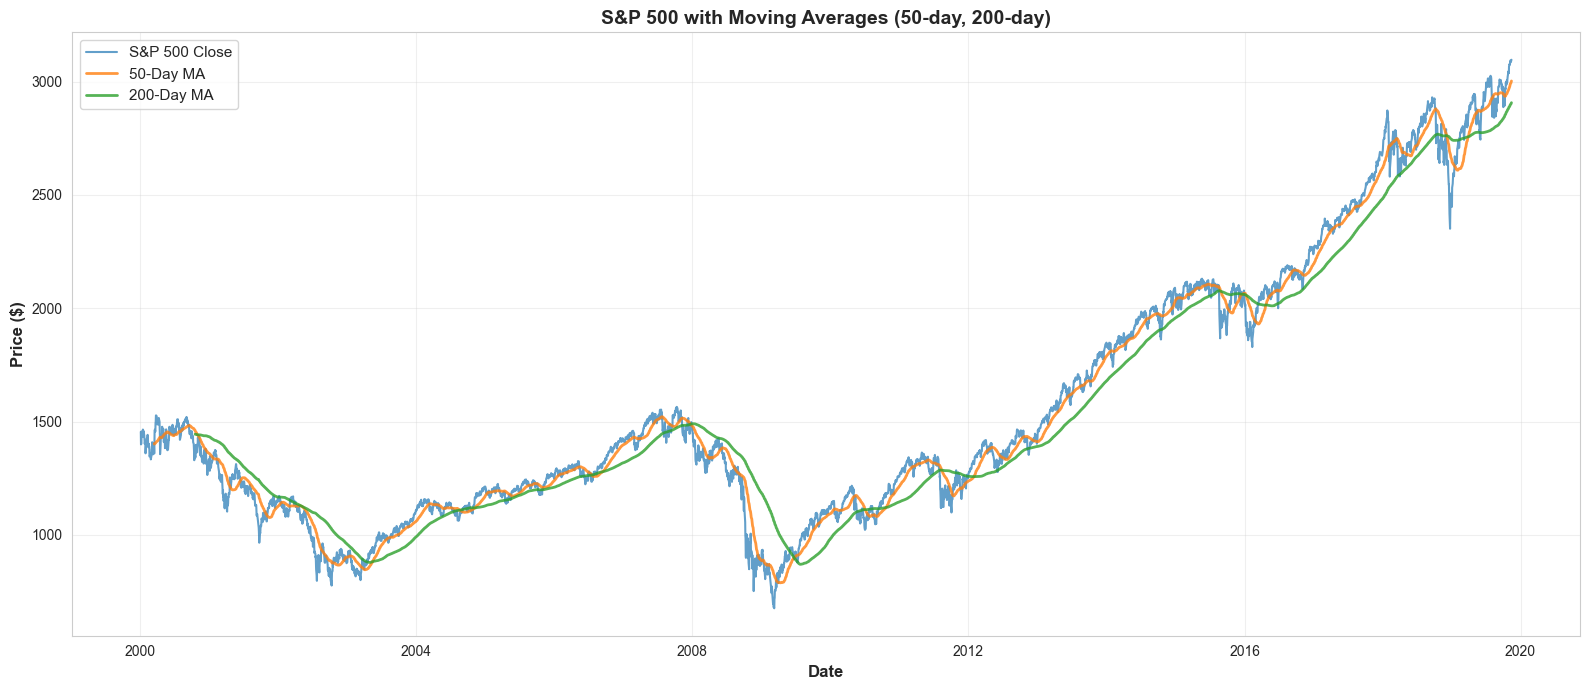

이동평균선 차트 생성 완료


In [7]:
# 이동평균선과 함께 표시
fig, ax = plt.subplots(figsize=(16, 7))

# 이동평균 계산
df_filtered['MA_50'] = df_filtered['Close'].rolling(window=50).mean()
df_filtered['MA_200'] = df_filtered['Close'].rolling(window=200).mean()

ax.plot(df_filtered['Date'], df_filtered['Close'], linewidth=1.5, color='#1f77b4', label='S&P 500 Close', alpha=0.7)
ax.plot(df_filtered['Date'], df_filtered['MA_50'], linewidth=2, color='#ff7f0e', label='50-Day MA', alpha=0.8)
ax.plot(df_filtered['Date'], df_filtered['MA_200'], linewidth=2, color='#2ca02c', label='200-Day MA', alpha=0.8)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax.set_title('S&P 500 with Moving Averages (50-day, 200-day)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print("이동평균선 차트 생성 완료")

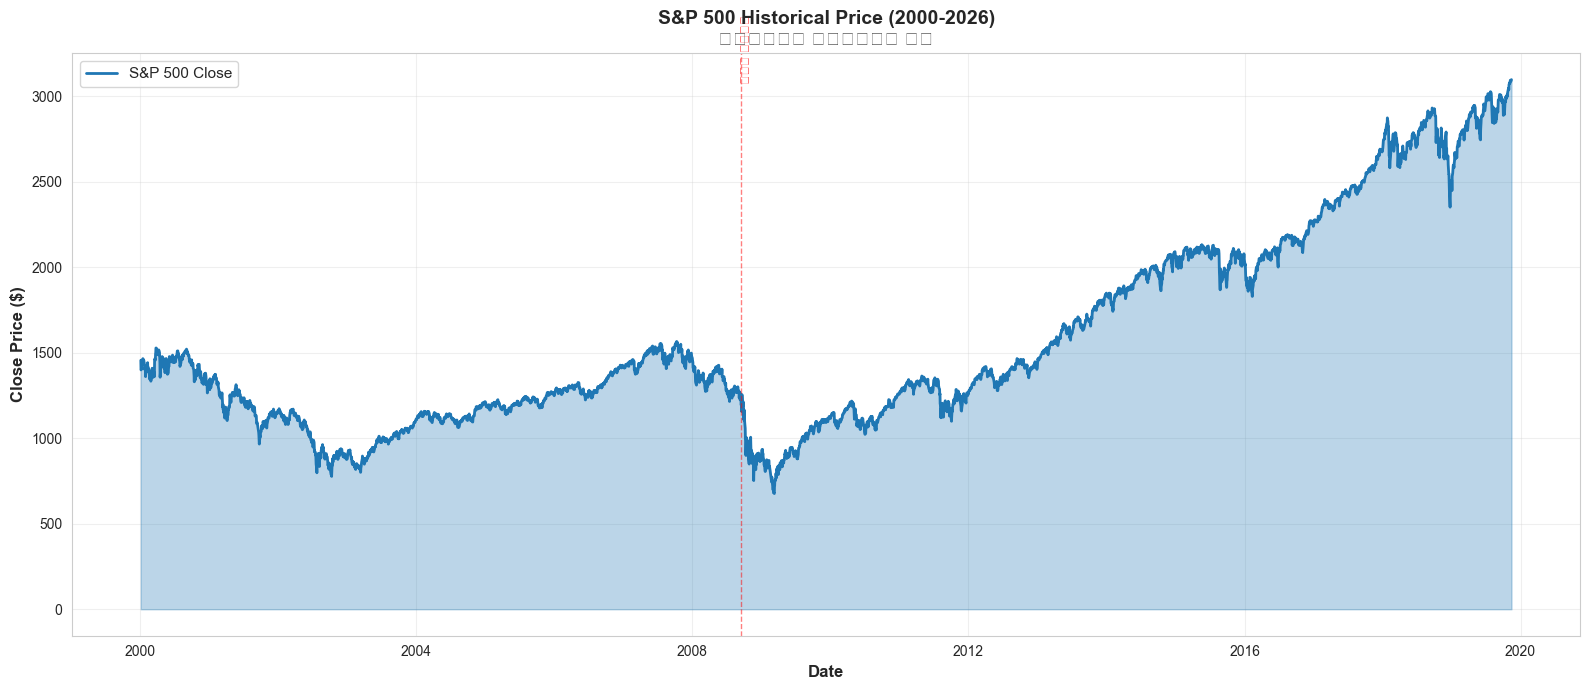

주요 시계열 차트 생성 완료


In [6]:
# 메인 시계열 그래프: 종가 라인그래프
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(df_filtered['Date'], df_filtered['Close'], linewidth=2, color='#1f77b4', label='S&P 500 Close')
ax.fill_between(df_filtered['Date'], df_filtered['Close'], alpha=0.3, color='#1f77b4')

# 주요 경제 위기 표시
crisis_events = {
    pd.Timestamp('2008-09-15'): '글로벌 금융위기',
    pd.Timestamp('2020-03-16'): 'COVID-19 크래시',
    pd.Timestamp('2022-12-28'): '베어마켓 바닥'
}

for date, event in crisis_events.items():
    if date in df_filtered['Date'].values:
        idx = df_filtered[df_filtered['Date'] == date].index
        if len(idx) > 0:
            ax.axvline(x=date, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax.text(date, ax.get_ylim()[1]*0.95, event, rotation=90, fontsize=9, color='red')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Close Price ($)', fontsize=12, fontweight='bold')
ax.set_title('S&P 500 Historical Price (2000-2026)\n과거시점에서 현재시점으로 추이', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print("주요 시계열 차트 생성 완료")

## 3. 시계열 시각화

2000년 1월부터 현재까지 S&P 500 종가 데이터를 라인그래프로 시각화합니다.

In [5]:
# 데이터 탐색
print("="*60)
print("데이터 개요")
print("="*60)
print(f"데이터 기간: {df_filtered['Date'].min().date()} ~ {df_filtered['Date'].max().date()}")
print(f"총 거래일 수: {len(df_filtered)}")
print(f"연도 범위: {df_filtered['Date'].dt.year.min()} ~ {df_filtered['Date'].dt.year.max()}")

print("\n" + "="*60)
print("종가(Close) 통계")
print("="*60)
close_stats = df_filtered['Close'].describe()
print(close_stats)

print(f"\n최고점: ${df_filtered['Close'].max():.2f} ({df_filtered[df_filtered['Close'] == df_filtered['Close'].max()]['Date'].values[0]})")
print(f"최저점: ${df_filtered['Close'].min():.2f} ({df_filtered[df_filtered['Close'] == df_filtered['Close'].min()]['Date'].values[0]})")
print(f"총 상승률: {((df_filtered['Close'].iloc[-1] / df_filtered['Close'].iloc[0]) - 1) * 100:.2f}%")

print("\n" + "="*60)
print("결측치 현황")
print("="*60)
missing_info = pd.DataFrame({
    'Column': df_filtered.columns,
    'Missing_Count': df_filtered.isnull().sum(),
    'Missing_Pct': (df_filtered.isnull().sum() / len(df_filtered) * 100).round(2)
})
print(missing_info)

데이터 개요
데이터 기간: 2000-01-03 ~ 2019-11-14
총 거래일 수: 5000
연도 범위: 2000 ~ 2019

종가(Close) 통계
count    5000.000000
mean     1565.181160
std       574.248865
min       676.500000
25%      1150.275000
50%      1358.200000
75%      1973.375000
max      3096.600000
Name: Close, dtype: float64

최고점: $3096.60 (2019-11-14T00:00:00.000000000)
최저점: $676.50 (2009-03-09T00:00:00.000000000)
총 상승률: 112.80%

결측치 현황
                Column  Missing_Count  Missing_Pct
Date              Date              0          0.0
Close            Close              0          0.0
Open              Open              0          0.0
High              High              0          0.0
Low                Low              0          0.0
Volume          Volume           5000        100.0
Change_Pct  Change_Pct              0          0.0


## 2. 데이터 탐색 및 기초 통계

필터링된 데이터의 형태, 날짜 범위, 기초 통계량을 확인합니다.

In [4]:
# 데이터 필터링: 2000년 1월 1일 ~ 2026년 6월 1일
start_date = pd.Timestamp('2000-01-01')
end_date = pd.Timestamp('2026-06-01')

df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

print(f"필터링 후 데이터 기간: {df_filtered['Date'].min()} ~ {df_filtered['Date'].max()}")
print(f"총 거래일 수: {len(df_filtered)}")
print(f"\n결측치 확인:")
print(df_filtered.isnull().sum())
print(f"\n기초 통계량:")
print(df_filtered[['Close', 'Open', 'High', 'Low']].describe())

필터링 후 데이터 기간: 2000-01-03 00:00:00 ~ 2019-11-14 00:00:00
총 거래일 수: 5000

결측치 확인:
Date             0
Close            0
Open             0
High             0
Low              0
Volume        5000
Change_Pct       0
dtype: int64

기초 통계량:
             Close         Open         High          Low
count  5000.000000  5000.000000  5000.000000  5000.000000
mean   1565.181160  1564.990500  1573.893580  1555.375560
std     574.248865   574.162272   574.935851   573.241574
min     676.500000   679.300000   695.300000   666.800000
25%    1150.275000  1150.450000  1158.525000  1140.950000
50%    1358.200000  1358.050000  1366.950000  1347.000000
75%    1973.375000  1974.275000  1983.375000  1965.150000
max    3096.600000  3090.800000  3102.600000  3084.700000


In [3]:
# 데이터 클랜징
# 1. 컬럼명 정리 (공백 제거 및 영문화)
df.columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct']

# 2. 날짜 포맷 정규화 (예: "2019- 11- 14" -> "2019-11-14")
df['Date'] = df['Date'].str.replace(' ', '', regex=False)
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# 3. 숫자 컬럼 처리 (쉼표 제거 및 숫자형 변환)
numeric_cols = ['Close', 'Open', 'High', 'Low']
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. 거래량 처리 (대부분 비어있으므로 제거 검토 필요)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# 5. 변동% 처리 (% 기호 제거)
df['Change_Pct'] = df['Change_Pct'].astype(str).str.replace('%', '', regex=False)
df['Change_Pct'] = pd.to_numeric(df['Change_Pct'], errors='coerce')

# 6. 시간순 정렬 (과거 -> 현재)
df = df.sort_values('Date').reset_index(drop=True)

print("클랜징 후 데이터 모양:", df.shape)
print("\n클랜징 후 첫 5행:")
print(df.head())
print("\n클랜징 후 마지막 5행:")
print(df.tail())
print("\n데이터 타입:")
print(df.dtypes)

클랜징 후 데이터 모양: (5000, 7)

클랜징 후 첫 5행:
        Date   Close    Open    High     Low  Volume  Change_Pct
0 2000-01-03  1455.2  1469.2  1478.0  1438.4     NaN       -0.95
1 2000-01-04  1399.4  1455.2  1455.2  1397.4     NaN       -3.83
2 2000-01-05  1402.1  1399.4  1413.3  1377.7     NaN        0.19
3 2000-01-06  1403.5  1402.1  1411.9  1392.0     NaN        0.10
4 2000-01-07  1441.5  1403.5  1441.5  1400.5     NaN        2.71

클랜징 후 마지막 5행:
           Date   Close    Open    High     Low  Volume  Change_Pct
4995 2019-11-08  3093.1  3081.2  3093.1  3073.6     NaN        0.26
4996 2019-11-11  3087.0  3080.3  3088.3  3075.8     NaN       -0.20
4997 2019-11-12  3091.8  3089.3  3102.6  3084.7     NaN        0.16
4998 2019-11-13  3094.0  3084.2  3098.1  3078.8     NaN        0.07
4999 2019-11-14  3096.6  3090.8  3098.2  3083.3     NaN        0.08

데이터 타입:
Date          datetime64[ns]
Close                float64
Open                 float64
High                 float64
Low                  floa

In [2]:
# CSV 파일 로드
file_path = r'c:\work\S&P 500 과거 데이터.csv'
df = pd.read_csv(file_path, encoding='utf-8')

print("원본 데이터 모양:", df.shape)
print("\n첫 5행:")
print(df.head())
print("\n컬럼 정보:")
print(df.info())

원본 데이터 모양: (5000, 7)

첫 5행:
             날짜        종가        시가        고가        저가  거래량    변동 %
0  2019- 11- 14  3,096.60  3,090.80  3,098.20  3,083.30  NaN   0.08%
1  2019- 11- 13  3,094.00  3,084.20  3,098.10  3,078.80  NaN   0.07%
2  2019- 11- 12  3,091.80  3,089.30  3,102.60  3,084.70  NaN   0.16%
3  2019- 11- 11  3,087.00  3,080.30  3,088.30  3,075.80  NaN  -0.20%
4  2019- 11- 08  3,093.10  3,081.20  3,093.10  3,073.60  NaN   0.26%

컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      5000 non-null   object 
 1   종가      5000 non-null   object 
 2   시가      5000 non-null   object 
 3   고가      5000 non-null   object 
 4   저가      5000 non-null   object 
 5   거래량     0 non-null      float64
 6   변동 %    5000 non-null   object 
dtypes: float64(1), object(6)
memory usage: 273.6+ KB
None


## 1. 데이터 로딩 및 클랜징

CSV 파일을 pandas로 로드하고 데이터 타입 변환, 날짜 포맷 정규화, 결측치 처리를 수행합니다.

In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# S&P 500 지수 과거 데이터 분석 (2000년 1월 - 2026년 6월)

이 노트북은 S&P 500 지수의 과거 데이터를 pandas를 활용해 체계적으로 분석합니다.
- 데이터 클랜징 및 검증
- 20년 이상의 시계열 데이터 분석
- 성과 지표 및 위험 분석
- 시각화를 통한 시장 트렌드 파악